In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from src.loading import load_gpm_feature_stats, load_imerg_feature_stats, load_dyamond

# GPM / IMERG vs DYAMOND: Feature Size Distributions

Compare the size distribution (`area_km2`) of precipitation features between the
GPM and IMERG observations and the DYAMOND global storm-resolving models,
following the style of the DYAMOND-vs-GPM comparison notebooks.

Two cases are shown side by side:

- **All features** — every feature returned by the loaders.
- **Fits in swath** — only features fully contained within a single satellite
  swath, rather than truncated by its edge.

The "fits in swath" flag is normalised into a shared `fits_swath` column:

- IMERG / DYAMOND use their `fits_in_swath` field directly.
- GPM has no `fits_in_swath`; its native-swath analog is *not touching the
  cross-track edge*, so `fits_swath = ~touches_cross_track_edge`.

Feature *area* (km²) is used as the size metric so it is comparable across
datasets despite differing native resolutions. The loaders apply the project's
standard cuts (`size_px >= 5`, `max_precip_mm_hr >= 10`, `|centroid_lat| <= 20`);
GPM is additionally stitched across its overlapping regions.

In [2]:
RESOLUTION = "0p05"
DYAMOND_MODELS = [
    "GEOS-3km",
    # "gSAM-4km",
    "ICON-SAP-5km",
    # "MPAS-3km",
    # "SCREAM-3km",
    "SHiELD-3km",
]

# Observations first (GPM, IMERG), then the DYAMOND models. Each dataset gets a
# normalised `fits_swath` boolean so the swath restriction is applied uniformly.
feature_data = {}
feature_data["GPM"] = load_gpm_feature_stats().with_columns(
    (~pl.col("touches_cross_track_edge")).alias("fits_swath")
)
feature_data["IMERG"] = load_imerg_feature_stats().with_columns(
    pl.col("fits_in_swath").alias("fits_swath")
)
for model in DYAMOND_MODELS:
    feature_data[model] = load_dyamond(model, RESOLUTION).with_columns(
        pl.col("fits_in_swath").alias("fits_swath")
    )

# Observations -> black (IMERG solid, GPM dashed); DYAMOND models -> color cycle.
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
plot_styles = {}
cycle_index = 0
for name in feature_data:
    if name == "IMERG":
        plot_styles[name] = {"color": "black", "lw": 4, "ls": "-"}
    elif name == "GPM":
        plot_styles[name] = {"color": "black", "lw": 3, "ls": "--"}
    else:
        plot_styles[name] = {"color": color_cycle[cycle_index % len(color_cycle)], "lw": 1.5, "ls": "-"}
        cycle_index += 1

for name, df in feature_data.items():
    print(f"{name:15s} n={df.height:7d}  fits_swath_frac={df['fits_swath'].mean():.3f}")

GPM             n=  79512  fits_swath_frac=0.726
IMERG           n=  31908  fits_swath_frac=0.308
GEOS-3km        n= 400416  fits_swath_frac=0.987
ICON-SAP-5km    n= 741866  fits_swath_frac=0.998
SHiELD-3km      n= 299259  fits_swath_frac=0.978


## Size distribution (CDF)

Cumulative distribution of feature area on a log x-axis, for all features (left)
and for only those features that fit within a single swath (right).

In [3]:
def plot_cdf(series: pl.Series, ax: plt.Axes = None, label: str = None, **kwargs):
    values = series.drop_nulls().sort().to_numpy()
    cdf = np.arange(1, len(values) + 1) / len(values)
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.get_figure()
    ax.plot(values, cdf, label=label, **kwargs)
    return fig, ax

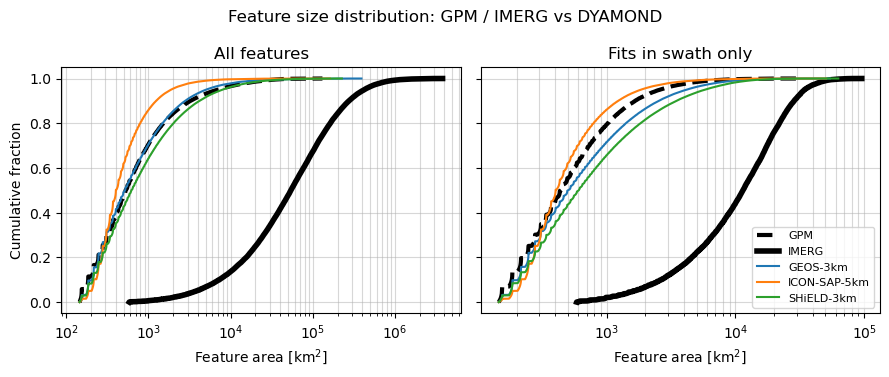

In [4]:
subsets = {
    "All features": lambda df: df,
    "Fits in swath only": lambda df: df.filter(pl.col("fits_swath")),
}

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharey=True)

for ax, (title, subset) in zip(axes, subsets.items()):
    for name, df in feature_data.items():
        plot_cdf(subset(df)["area_km2"], ax=ax, label=name, **plot_styles[name])
    ax.set_xscale("log")
    ax.set_xlabel("Feature area [km$^2$]")
    ax.set_title(title)
    ax.grid(alpha=0.5, which="both")

axes[0].set_ylabel("Cumulative fraction")
axes[1].legend(loc="lower right", fontsize=8)
fig.suptitle("Feature size distribution: GPM / IMERG vs DYAMOND")
fig.tight_layout()

## Median feature size

Median feature area for each dataset, comparing all features against the
fits-in-swath subset. Because large features are the ones most likely to be
truncated by a swath edge, restricting to fits-in-swath removes the biggest
features and so lowers the median — most strongly for IMERG.

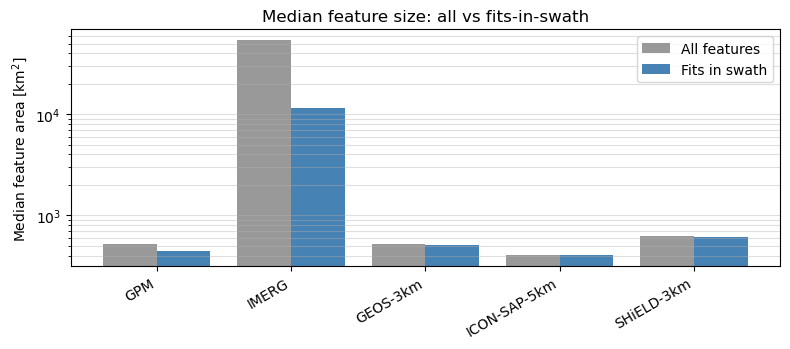

In [5]:
names = list(feature_data.keys())
med_all = [feature_data[n]["area_km2"].median() for n in names]
med_fits = [feature_data[n].filter(pl.col("fits_swath"))["area_km2"].median() for n in names]

x = np.arange(len(names))
w = 0.4
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(x - w / 2, med_all, w, label="All features", color="0.6")
ax.bar(x + w / 2, med_fits, w, label="Fits in swath", color="steelblue")
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=30, ha="right")
ax.set_ylabel("Median feature area [km$^2$]")
ax.set_title("Median feature size: all vs fits-in-swath")
ax.legend()
ax.grid(alpha=0.4, axis="y", which="both")
fig.tight_layout()

## Size distribution (CDF), small features only

Same comparison as above but restricted to features smaller than
`1e4 km^2`, to focus on the small-feature end of the distribution where the
DYAMOND models live and to remove the large IMERG features that dominate the
full-range view.

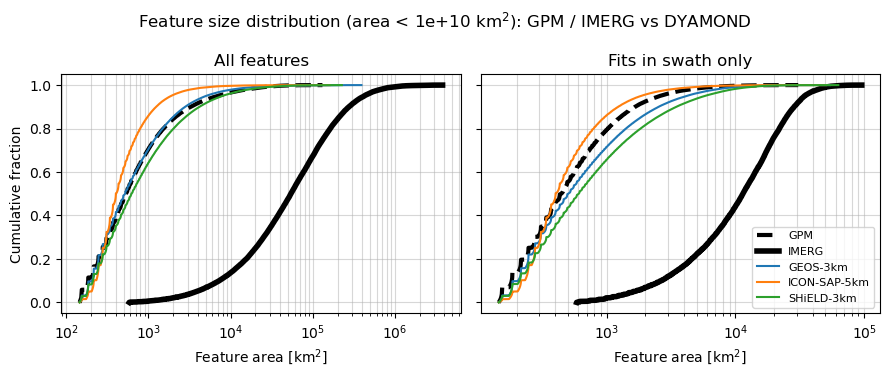

In [6]:
AREA_MAX = 1e10  # km^2

subsets_small = {
    "All features": lambda df: df.filter(pl.col("area_km2") < AREA_MAX),
    "Fits in swath only": lambda df: df.filter(
        pl.col("fits_swath") & (pl.col("area_km2") < AREA_MAX)
    ),
}

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharey=True)

for ax, (title, subset) in zip(axes, subsets_small.items()):
    for name, df in feature_data.items():
        plot_cdf(subset(df)["area_km2"], ax=ax, label=name, **plot_styles[name])
    ax.set_xscale("log")
    ax.set_xlabel("Feature area [km$^2$]")
    ax.set_title(title)
    ax.grid(alpha=0.5, which="both")

axes[0].set_ylabel("Cumulative fraction")
axes[1].legend(loc="lower right", fontsize=8)
fig.suptitle(f"Feature size distribution (area < {AREA_MAX:.0e} km$^2$): GPM / IMERG vs DYAMOND")
fig.tight_layout()

## Size distribution (PDF)

The same distributions as the CDFs above, shown as probability densities.

Because feature area spans several orders of magnitude, the histogram uses
**logarithmically spaced bins** and the density is taken with respect to
`log10(area)`, i.e. each curve integrates to 1 over the log axis. This is the
form that makes the peak (modal feature size) of each dataset directly
comparable; a linear-bin density on a log axis would be visually misleading.

In [7]:
def plot_pdf(
    series: pl.Series,
    ax: plt.Axes = None,
    label: str = None,
    bins: np.ndarray = None,
    **kwargs,
):
    """Density of log10(area), plotted at bin centres on a log x-axis."""
    values = series.drop_nulls().to_numpy()
    values = values[values > 0]
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.get_figure()
    counts, edges = np.histogram(np.log10(values), bins=bins, density=True)
    centers = 10 ** (0.5 * (edges[:-1] + edges[1:]))
    ax.plot(centers, counts, label=label, **kwargs)
    return fig, ax


def log_bins(datasets, bins_per_decade: int = 6):
    """Shared log10-spaced bin edges spanning every dataset passed in.

    Bin width is set per decade rather than by a fixed bin count so the wide-range
    and small-feature plots get comparable resolution. Feature area is quantised
    (area ~ size_px * pixel_area), so bins much finer than ~6 per decade start
    resolving individual pixel counts and the PDF develops a sawtooth.
    """
    lo = min(float(d.min()) for d in datasets if d.len() > 0)
    hi = max(float(d.max()) for d in datasets if d.len() > 0)
    lo10, hi10 = np.log10(lo), np.log10(hi)
    n_bins = max(1, int(round((hi10 - lo10) * bins_per_decade)))
    return np.linspace(lo10, hi10, n_bins + 1)

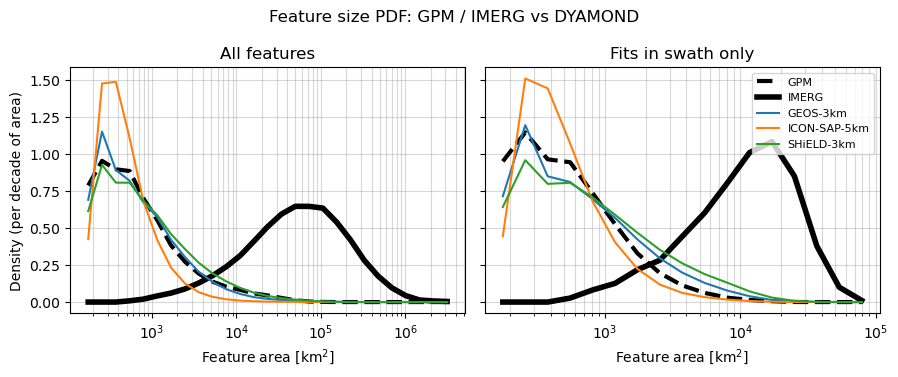

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharey=True)

for ax, (title, subset) in zip(axes, subsets.items()):
    series = [subset(df)["area_km2"] for df in feature_data.values()]
    bins = log_bins(series)
    for name, df in feature_data.items():
        plot_pdf(subset(df)["area_km2"], ax=ax, label=name, bins=bins, **plot_styles[name])
    ax.set_xscale("log")
    ax.set_xlabel("Feature area [km$^2$]")
    ax.set_title(title)
    ax.grid(alpha=0.5, which="both")

axes[0].set_ylabel("Density (per decade of area)")
axes[1].legend(loc="upper right", fontsize=8)
fig.suptitle("Feature size PDF: GPM / IMERG vs DYAMOND")
fig.tight_layout()

## Size distribution (PDF), small features only

The small-feature counterpart of the PDF above, restricted to features smaller
than `1e4 km^2`. Note the bins are recomputed over this restricted range and each
curve is renormalised within it, so this is the distribution *conditional on*
being a small feature — the relative heights say nothing about how much of each
dataset falls below the cutoff in the first place.

GPM             frac(area < 1e+10 km2) = 1.000
IMERG           frac(area < 1e+10 km2) = 1.000
GEOS-3km        frac(area < 1e+10 km2) = 1.000
ICON-SAP-5km    frac(area < 1e+10 km2) = 1.000
SHiELD-3km      frac(area < 1e+10 km2) = 1.000


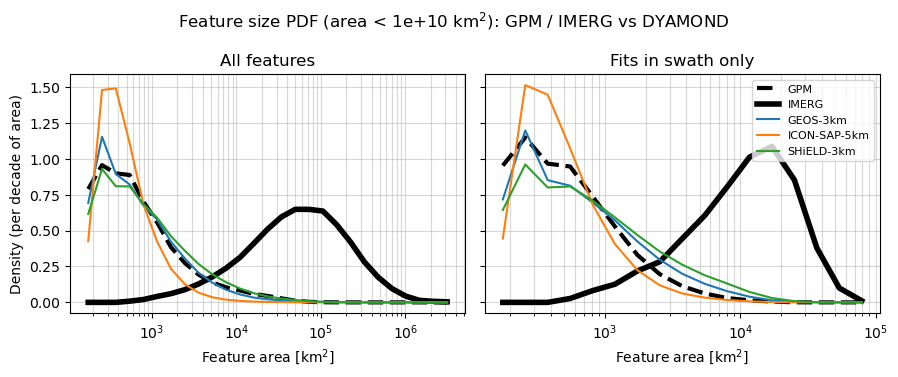

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharey=True)

for ax, (title, subset) in zip(axes, subsets_small.items()):
    series = [subset(df)["area_km2"] for df in feature_data.values()]
    bins = log_bins(series)
    for name, df in feature_data.items():
        plot_pdf(subset(df)["area_km2"], ax=ax, label=name, bins=bins, **plot_styles[name])
    ax.set_xscale("log")
    ax.set_xlabel("Feature area [km$^2$]")
    ax.set_title(title)
    ax.grid(alpha=0.5, which="both")

axes[0].set_ylabel("Density (per decade of area)")
axes[1].legend(loc="upper right", fontsize=8)
fig.suptitle(f"Feature size PDF (area < {AREA_MAX:.0e} km$^2$): GPM / IMERG vs DYAMOND")
fig.tight_layout()

# Fraction of each dataset that actually falls below the cutoff.
for name, df in feature_data.items():
    frac = (df["area_km2"] < AREA_MAX).mean()
    print(f"{name:15s} frac(area < {AREA_MAX:.0e} km2) = {frac:.3f}")